# Segmentación de superficies geométricas — pieza cilíndrica

La pieza es aproximadamente cilíndrica con:
- **Caras planas** (tapas, agujeros, indentaciones): normales apuntando en ±Z
- **Superficies cilíndricas** (paredes laterales): normales apuntando radialmente

**Estrategia:**
1. Cargar nube XYZ calibrada
2. Estimar normales locales con SG 2D (paraboloide)
3. Proyectar normales en esfera unitaria → clusterizar por dirección
4. Ajustar primitivas geométricas (plano / cilindro) a cada cluster
5. Visualizar la segmentación

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cv2
import os, sys
from scipy.spatial import cKDTree


sys.path.insert(0, os.path.abspath(".."))
import camera.raw as raw

## 1. Cargar datos XYZ

In [2]:
SAMPLE = "151225_160136_P44512_S2_7761"
BASE   = f"../gears_defectos_xyz_etiquetados/{SAMPLE}/debug/entities"

xyz = raw.read_img_raw(f"{BASE}/save_xyz/{SAMPLE}_save_xyz.raw")
H, W = xyz.shape[:2]
X, Y, Z = xyz[:, :, 0], xyz[:, :, 1], xyz[:, :, 2]

valid = np.isfinite(Z) & (Z != 0)

print(f"Shape : {xyz.shape}")
print(f"Píxeles válidos: {valid.sum()} / {H*W}")
print(f"X: [{X[valid].min():.3f}, {X[valid].max():.3f}] mm")
print(f"Y: [{Y[valid].min():.3f}, {Y[valid].max():.3f}] mm")
print(f"Z: [{Z[valid].min():.3f}, {Z[valid].max():.3f}] mm")

Shape : (790, 1129, 3)
Píxeles válidos: 746268 / 891910
X: [-59.985, 88.030] mm
Y: [-48.351, 48.657] mm
Z: [0.100, 21.330] mm


In [3]:
# ── Cargar máscara de defecto PRONTO (para excluirla de la clasificación) ─────
# Se repite más adelante (celda 7a) para obtener los polígonos y el plot.
_mask_path_early = f"{BASE}/rgb_seg/{SAMPLE}_rgb_seg.txt"
_mask_early_raw  = np.zeros((H, W), dtype=np.uint8)
with open(_mask_path_early) as _f:
    for _line in _f:
        _vals = _line.strip().split()
        if len(_vals) < 5: continue
        _coords = np.array(_vals[1:], dtype=float).reshape(-1, 2)
        _pts_px = (_coords * np.array([W, H])).astype(np.int32)
        cv2.fillPoly(_mask_early_raw, [_pts_px], 1)

EROSION_PX = 5
_ker_er = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*EROSION_PX+1, 2*EROSION_PX+1))
defect_mask_early = cv2.erode(_mask_early_raw, _ker_er).astype(bool)

print(f"Máscara defecto (temprana, erosión {EROSION_PX}px): {defect_mask_early.sum()} px")


Máscara defecto (temprana, erosión 5px): 4150 px


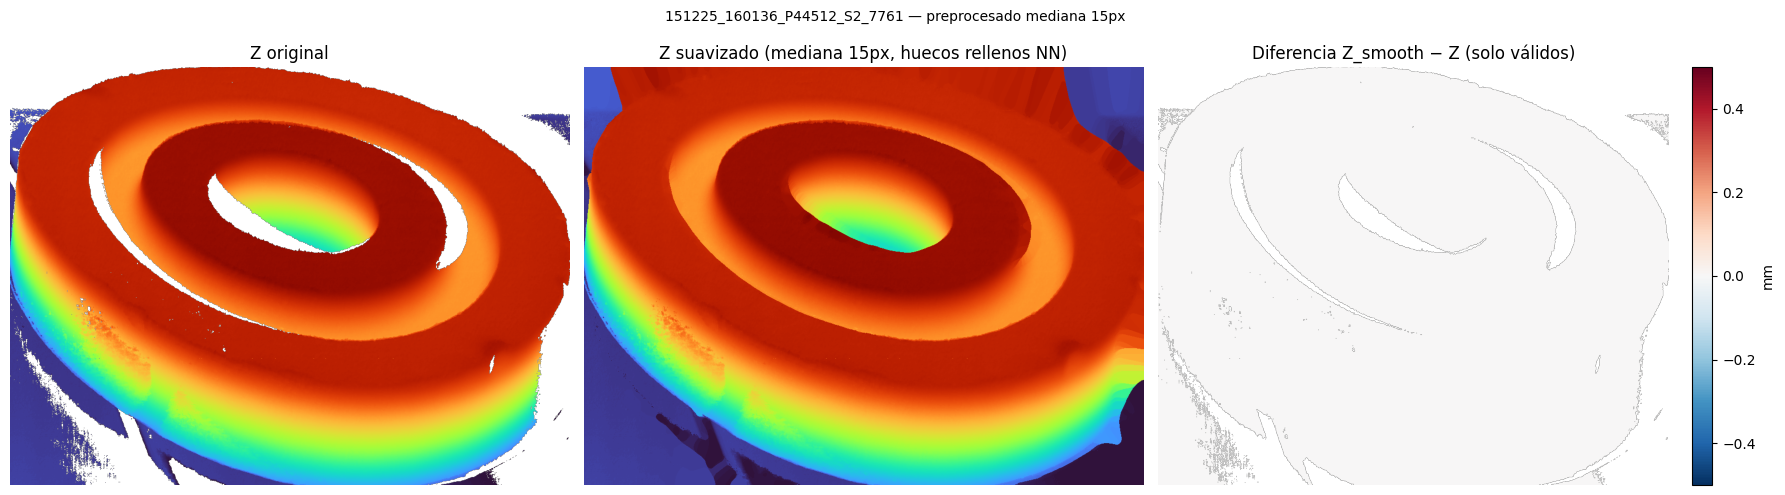

Huecos rellenados por NN+mediana: 145642 px
Dif. en válidos — max abs: 0.0000 mm  std: 0.0000 mm


In [4]:
# ── Filtro de mediana para rellenar huecos y suavizar ruido ──────────────────
from scipy.ndimage import median_filter

MED_WIN = 15   # tamaño de ventana (px, impar). Aumentar si hay muchos huecos.

# Donde es inválido metemos el valor más cercano antes del filtro:
# una mediana sobre una imagen con ceros enormes contaminaría los bordes.
# → usamos nearest-neighbor fill (propagación) antes de filtrar.
from scipy.ndimage import distance_transform_edt

# Fill nan/cero por el píxel válido más cercano
fill_idx = distance_transform_edt(~valid, return_distances=False, return_indices=True)
Z_filled_nn = Z[tuple(fill_idx)]   # cada px inválido toma el Z del válido más cercano

# Ahora mediana sobre imagen sin huecos
Z_med = median_filter(Z_filled_nn.astype(np.float64), size=MED_WIN)

# Resultado: válidos conservan su Z original; inválidos toman la mediana filtrada
Z_smooth = np.where(valid, Z.astype(float), Z_med)

# Diagnóstico: diferencia en zona válida (el SG con huecos rellenos)
diff_med = np.where(valid, Z_smooth - Z.astype(float), np.nan)

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(np.where(valid, Z, np.nan), cmap='turbo', aspect='auto')
axes[0].set_title('Z original'); axes[0].axis('off')

axes[1].imshow(Z_smooth, cmap='turbo', aspect='auto')
axes[1].set_title(f'Z suavizado (mediana {MED_WIN}px, huecos rellenos NN)'); axes[1].axis('off')

im2 = axes[2].imshow(diff_med, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
plt.colorbar(im2, ax=axes[2], label='mm', fraction=0.046, pad=0.04)
axes[2].set_title('Diferencia Z_smooth − Z (solo válidos)'); axes[2].axis('off')

plt.suptitle(f'{SAMPLE} — preprocesado mediana {MED_WIN}px', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Huecos rellenados por NN+mediana: {(~valid).sum()} px")
print(f"Dif. en válidos — max abs: {np.nanmax(np.abs(diff_med)):.4f} mm  "
      f"std: {np.nanstd(diff_med):.4f} mm")


## 2. Estimar normales locales con SG 2D

El filtro SG 2D ajusta un paraboloide local:  
$Z \approx a x^2 + b y^2 + c xy + d x + e y + f_0$

La normal en cada punto es proporcional a $(-d/s, -e/s, 1)$ normalizada,  
donde $s$ es la escala mm/px. Esto da la dirección normal en coordenadas 3D.

- **Normal ≈ (0,0,1)** → cara plana (tapa)  
- **Normal ≈ (nx, ny, 0)** → pared cilíndrica o lateral

In [5]:
SG_WIN_PX = 21   # ventana SG (impar). Aumentar para suavizar más.

def sg2d(Z_in, win):
    """SG 2D paraboloide. Devuelve tensor (H,W,6): [a,b,c,gx,gy,f0]."""
    assert win % 2 == 1
    hw = win // 2
    yi, xi = np.mgrid[-hw:hw+1, -hw:hw+1]
    reg = np.stack([xi**2, yi**2, xi*yi, xi, yi, np.ones_like(xi)], axis=-1)
    A   = reg.reshape(-1, 6)
    P   = np.linalg.inv(A.T @ A) @ A.T
    ks  = P.reshape(6, win, win)
    return np.stack(
        [cv2.filter2D(Z_in.astype(np.float64), -1, k,
                      borderType=cv2.BORDER_REFLECT) for k in ks],
        axis=-1
    )

# Resolución mm/px
dx = (X[valid].max() - X[valid].min()) / W
dy = (Y[valid].max() - Y[valid].min()) / H
pix_mm = float((dx + dy) / 2)
print(f"Resolución: {pix_mm:.4f} mm/px")

# Usar Z_smooth (mediana aplicada) para el SG 2D
coefs = sg2d(Z_smooth, SG_WIN_PX)

# Gradientes en mm/mm (convertir de px a mm)
Gx = coefs[..., 3] / pix_mm   # dZ/dX_mm
Gy = coefs[..., 4] / pix_mm   # dZ/dY_mm

# Normal no normalizada: n = (-Gx, -Gy, 1)
norm_len = np.sqrt(Gx**2 + Gy**2 + 1.0)
Nx = -Gx / norm_len
Ny = -Gy / norm_len
Nz =  1.0 / norm_len

# Ángulo cenital: θ=0 → normal apunta en Z (tapa); θ=90° → normal horizontal (pared)
theta = np.degrees(np.arccos(np.clip(np.abs(Nz), 0, 1)))

print(f"θ mediana (válidos): {np.median(theta[valid]):.1f}°")
print(f"θ percentiles [5,25,50,75,95]: {np.percentile(theta[valid],[5,25,50,75,95]).round(1)}")


Resolución: 0.1269 mm/px
θ mediana (válidos): 18.3°
θ percentiles [5,25,50,75,95]: [ 0.4  1.2 18.3 33.  51.6]


## 3. Visualización de normales y ángulo cenital

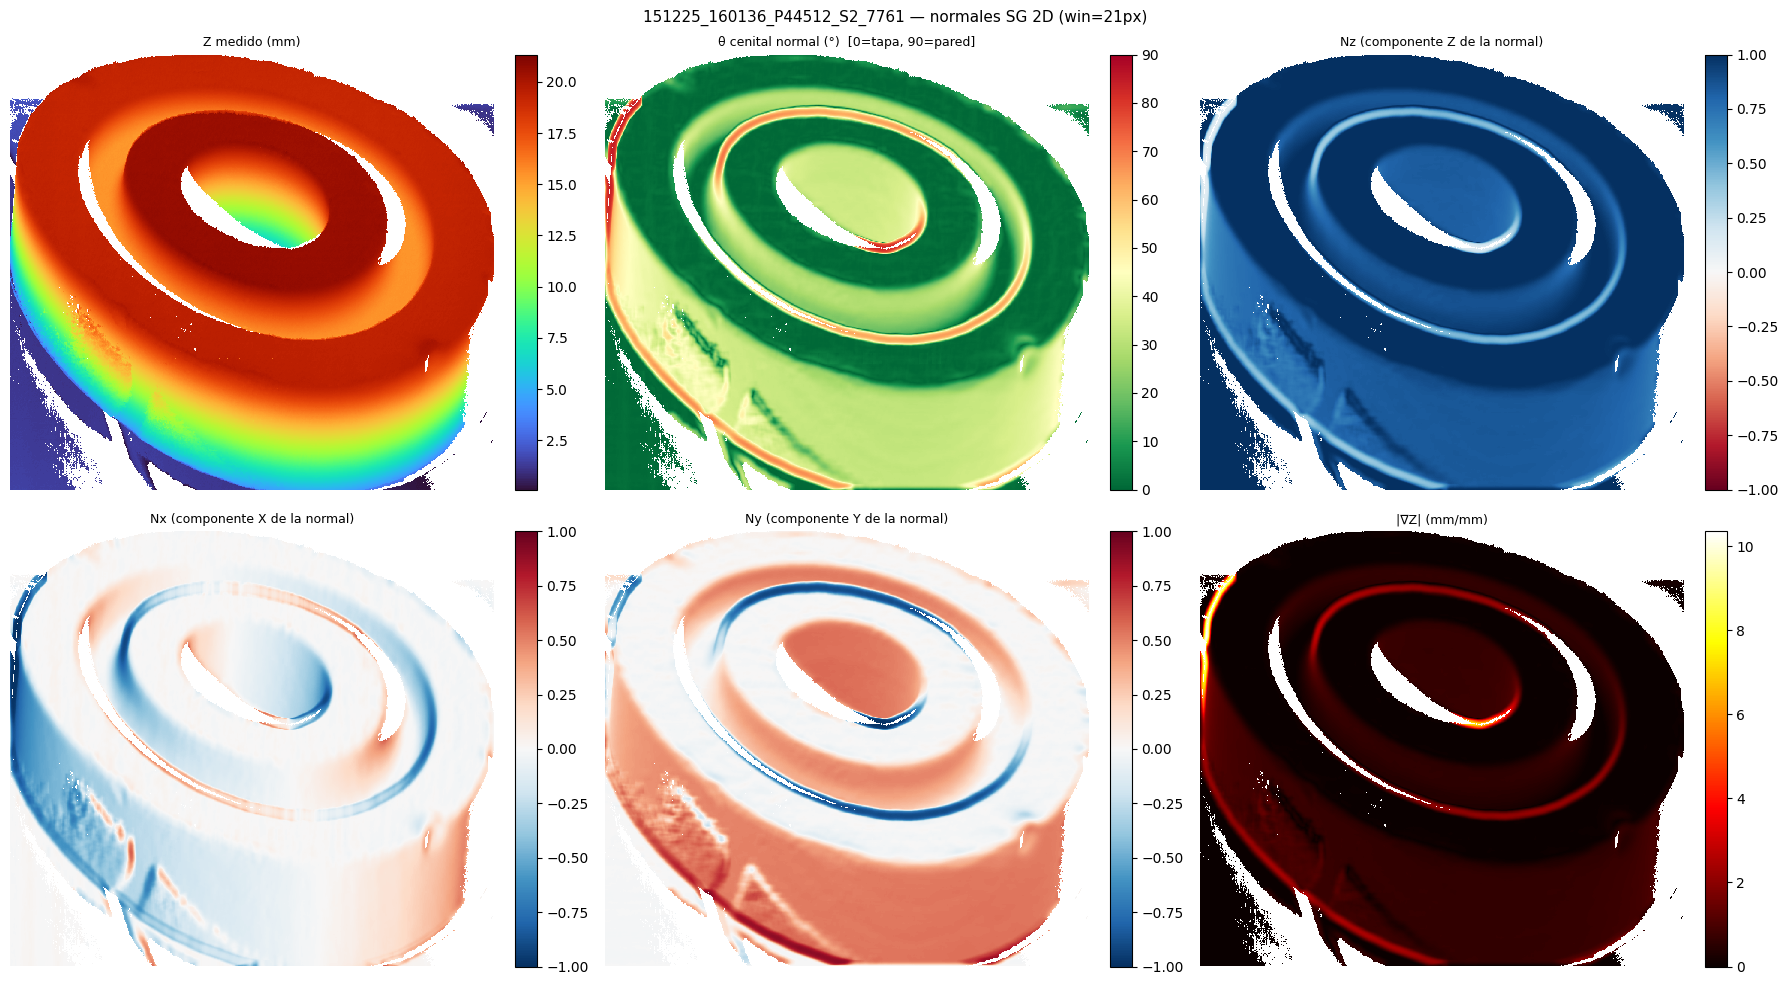

In [6]:
plt.close("all")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

theta_disp = np.where(valid, theta, np.nan)
nz_disp    = np.where(valid, Nz,    np.nan)
nx_disp    = np.where(valid, Nx,    np.nan)
ny_disp    = np.where(valid, Ny,    np.nan)
z_disp     = np.where(valid, Z,     np.nan)
grad_disp  = np.where(valid, np.sqrt(Gx**2 + Gy**2), np.nan)

panels = [
    (z_disp,     'turbo',  None,  None,  'Z medido (mm)'),
    (theta_disp, 'RdYlGn_r', 0,  90,    'θ cenital normal (°)  [0=tapa, 90=pared]'),
    (nz_disp,    'RdBu',   -1,   1,     'Nz (componente Z de la normal)'),
    (nx_disp,    'RdBu_r', -1,   1,     'Nx (componente X de la normal)'),
    (ny_disp,    'RdBu_r', -1,   1,     'Ny (componente Y de la normal)'),
    (grad_disp,  'hot',    0,    None,  '|∇Z| (mm/mm)'),
]

for ax, (data, cmap, vmin, vmax, title) in zip(axes.ravel(), panels):
    kw = dict(aspect='auto', interpolation='nearest')
    if vmin is not None: kw['vmin'] = vmin
    if vmax is not None: kw['vmax'] = vmax
    im = ax.imshow(data, cmap=cmap, **kw)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle(f'{SAMPLE} — normales SG 2D (win={SG_WIN_PX}px)', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Segmentación por ángulo cenital

Umbral simple: `θ < THR_TAPA` → cara plana; resto → superficie lateral.  
Después se refinará con clustering (sección 5).

Cara plana (θ<30.0°): 461153 px  (61.8%)
Pared      (θ≥30.0°): 281128 px  (37.7%)
(excluidos zona defecto: 3987 px)


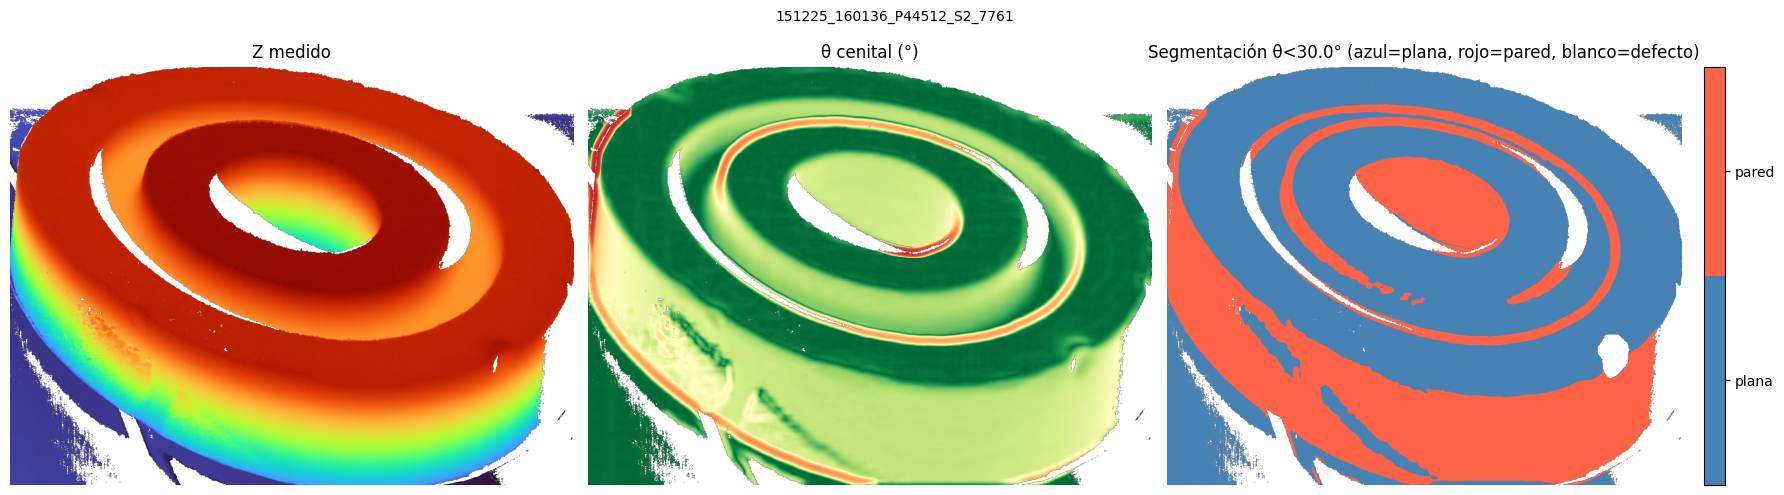

In [7]:
THR_TAPA_DEG = 30.0   # ángulo máximo para considerar «cara plana»

# Excluir zona del defecto: sus normales pueden estar distorsionadas por el golpe
seg_flat = valid & (theta < THR_TAPA_DEG)  & ~defect_mask_early   # cara plana
seg_wall = valid & (theta >= THR_TAPA_DEG) & ~defect_mask_early   # pared lateral

print(f"Cara plana (θ<{THR_TAPA_DEG}°): {seg_flat.sum():6d} px  ({100*seg_flat.sum()/valid.sum():.1f}%)")
print(f"Pared      (θ≥{THR_TAPA_DEG}°): {seg_wall.sum():6d} px  ({100*seg_wall.sum()/valid.sum():.1f}%)")
print(f"(excluidos zona defecto: {(valid & defect_mask_early).sum()} px)")

seg_img = np.full((H, W), np.nan)
seg_img[seg_flat] = 0.0
seg_img[seg_wall] = 1.0

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(np.where(valid, Z, np.nan), cmap='turbo', aspect='auto')
axes[0].set_title('Z medido'); axes[0].axis('off')

axes[1].imshow(theta_disp, cmap='RdYlGn_r', vmin=0, vmax=90, aspect='auto')
axes[1].set_title(f'θ cenital (°)'); axes[1].axis('off')

cmap2 = mcolors.ListedColormap(['steelblue', 'tomato'])
im2 = axes[2].imshow(seg_img, cmap=cmap2, vmin=-0.5, vmax=1.5, aspect='auto')
plt.colorbar(im2, ax=axes[2], ticks=[0, 1], fraction=0.046, pad=0.04).set_ticklabels(['plana', 'pared'])
axes[2].set_title(f'Segmentación θ<{THR_TAPA_DEG}° (azul=plana, rojo=pared, blanco=defecto)')
axes[2].axis('off')

plt.suptitle(SAMPLE, fontsize=10)
plt.tight_layout()
plt.show()


## 5. Subdivisión de caras planas por nivel de Z

Las caras planas tienen **Z constante** en cada superficie.  
Un histograma de Z en `seg_flat` revelará los distintos niveles (agujeros, tapas, indentaciones).
Luego se separan con un umbral por valle (o KDE + picos).

Niveles de Z detectados: 5
  Z ≈ 1.268 mm  (altura pico = 7085)
  Z ≈ 15.492 mm  (altura pico = 3223)
  Z ≈ 16.624 mm  (altura pico = 1693)
  Z ≈ 19.313 mm  (altura pico = 27910)
  Z ≈ 20.516 mm  (altura pico = 15174)


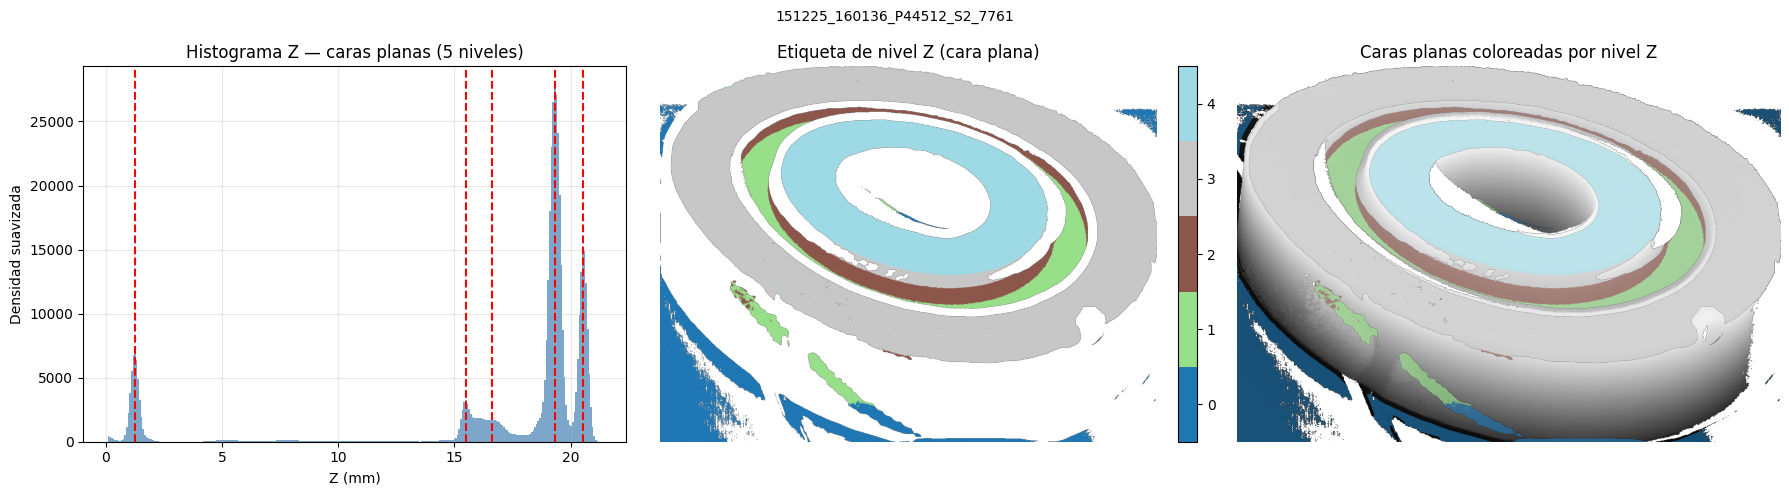

In [8]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

z_flat = Z[seg_flat]

# Histograma suavizado para detectar picos de Z
N_BINS = 300
counts, edges = np.histogram(z_flat, bins=N_BINS)
centers = (edges[:-1] + edges[1:]) / 2
smooth  = gaussian_filter1d(counts.astype(float), sigma=2.0)

peaks, props = find_peaks(smooth, height=smooth.max() * 0.05,
                           distance=N_BINS // 20)

print(f"Niveles de Z detectados: {len(peaks)}")
for p in peaks:
    print(f"  Z ≈ {centers[p]:.3f} mm  (altura pico = {smooth[p]:.0f})")

# Asignar cada px plano al pico más cercano
peak_z = centers[peaks]
dist_to_peaks = np.abs(z_flat[:, None] - peak_z[None, :])  # (N, K)
z_label = np.argmin(dist_to_peaks, axis=1)

# Imagen de etiquetas
flat_label_img = np.full((H, W), -1, dtype=int)
flat_label_img[seg_flat] = z_label

# ── Plot ─────────────────────────────────────────────────────────────────────
K_flat = len(peaks)
colors_flat = plt.cm.tab20(np.linspace(0, 1, max(K_flat, 1)))
cmap_flat = mcolors.ListedColormap(colors_flat)

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma Z
axes[0].bar(centers, smooth, width=centers[1]-centers[0],
            color='steelblue', alpha=0.7, label='KDE')
for p in peaks:
    axes[0].axvline(centers[p], color='red', lw=1.5, ls='--')
axes[0].set_xlabel('Z (mm)');  axes[0].set_ylabel('Densidad suavizada')
axes[0].set_title(f'Histograma Z — caras planas ({K_flat} niveles)')
axes[0].grid(alpha=0.3)

# Mapa de nivel Z
disp = np.where(flat_label_img >= 0, flat_label_img, np.nan)
im1 = axes[1].imshow(disp, cmap=cmap_flat, vmin=-0.5, vmax=K_flat - 0.5, aspect='auto')
plt.colorbar(im1, ax=axes[1], ticks=range(K_flat), fraction=0.046, pad=0.04)
axes[1].set_title('Etiqueta de nivel Z (cara plana)')
axes[1].axis('off')

# Paredes en gris encima
axes[2].imshow(np.where(valid, Z, np.nan), cmap='gray', aspect='auto')
over = np.zeros((H, W, 4), dtype=float)
for k in range(K_flat):
    mask_k = flat_label_img == k
    c = colors_flat[k]
    over[mask_k] = [c[0], c[1], c[2], 0.65]
axes[2].imshow(over, aspect='auto')
axes[2].set_title('Caras planas coloreadas por nivel Z')
axes[2].axis('off')

plt.suptitle(SAMPLE, fontsize=10)
plt.tight_layout()
plt.show()

## 6. Subdivisión de paredes por dirección azimutal de la normal

En paredes cilíndricas la normal proyectada en XY apunta radialmente.  
El ángulo azimutal φ = atan2(Ny, Nx) agrupa píxeles de la misma cara lateral.

Para una pieza centrada en $(cx, cy)$, se puede contrastar la dirección de la normal  
con el vector radial del punto para validar que es realmente cilíndrica.

Centro aproximado pieza: (-22.376, 2.825) mm
Coherencia radial — media: 0.001  std: 0.449


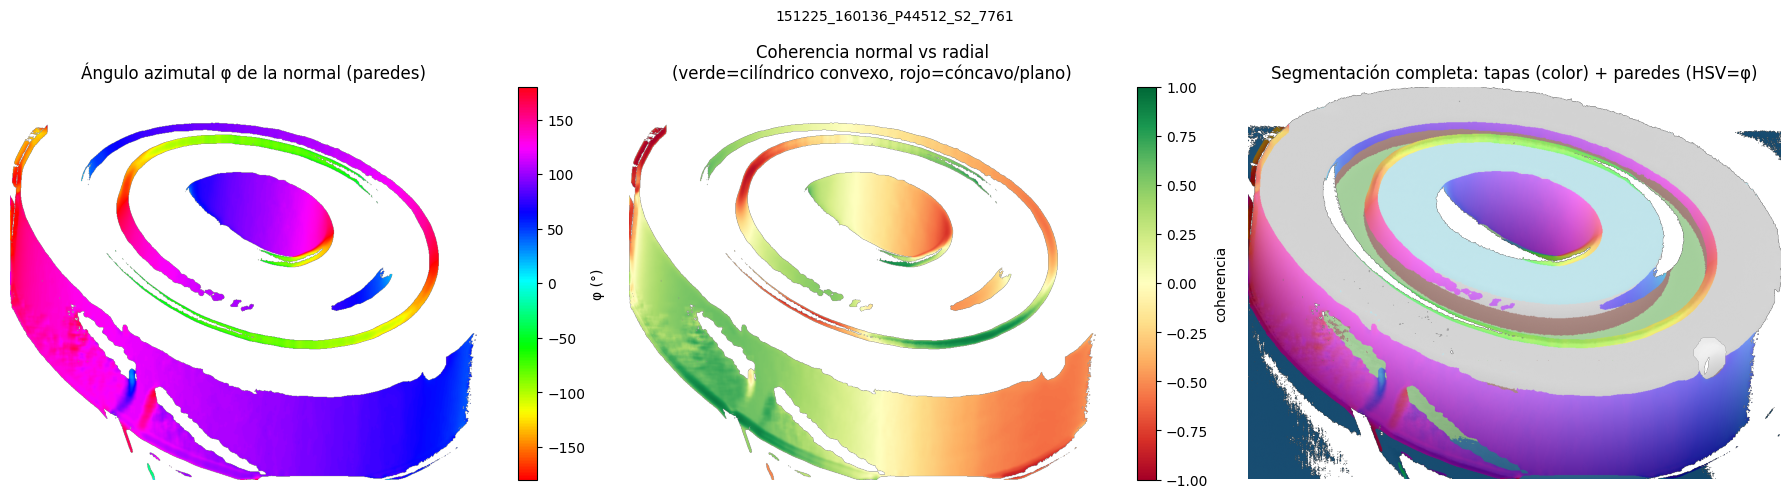

In [9]:
phi = np.degrees(np.arctan2(Ny, Nx))   # [-180, 180]
phi_disp = np.where(seg_wall, phi, np.nan)

# Centro aproximado de la pieza (media de puntos de pared)
cx_piece = float(X[seg_wall].mean())
cy_piece = float(Y[seg_wall].mean())
print(f"Centro aproximado pieza: ({cx_piece:.3f}, {cy_piece:.3f}) mm")

# Para cada px de pared: vector radial esperado vs normal medida
rx = X[seg_wall] - cx_piece
ry = Y[seg_wall] - cy_piece
r_len = np.sqrt(rx**2 + ry**2) + 1e-9
rx /= r_len;  ry /= r_len

# Coherencia: dot(normal_xy, radial)
nx_w = Nx[seg_wall];  ny_w = Ny[seg_wall]
coherence = rx * nx_w + ry * ny_w  # ≈1 si normal apunta hacia fuera (cilindro convexo)

coh_img = np.full((H, W), np.nan)
coh_img[seg_wall] = coherence

print(f"Coherencia radial — media: {coherence.mean():.3f}  std: {coherence.std():.3f}")

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(phi_disp, cmap='hsv', vmin=-180, vmax=180, aspect='auto')
plt.colorbar(im0, ax=axes[0], label='φ (°)', fraction=0.046, pad=0.04)
axes[0].set_title('Ángulo azimutal φ de la normal (paredes)')
axes[0].axis('off')

im1 = axes[1].imshow(coh_img, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im1, ax=axes[1], label='coherencia', fraction=0.046, pad=0.04)
axes[1].set_title('Coherencia normal vs radial\n(verde=cilíndrico convexo, rojo=cóncavo/plano)')
axes[1].axis('off')

# Vista conjunta: caras planas (tab20) + paredes (φ→HSV)
axes[2].imshow(np.where(valid, Z, np.nan), cmap='gray', aspect='auto')
over2 = np.zeros((H, W, 4), dtype=float)
for k in range(K_flat):
    mask_k = flat_label_img == k
    c = colors_flat[k]
    over2[mask_k] = [c[0], c[1], c[2], 0.6]
# Paredes: color por φ normalizado
phi_norm = (phi + 180) / 360.0
wall_rgba = plt.cm.hsv(phi_norm)
wall_rgba[..., 3] = 0.5
over2[seg_wall] = wall_rgba[seg_wall]
axes[2].imshow(over2, aspect='auto')
axes[2].set_title('Segmentación completa: tapas (color) + paredes (HSV=φ)')
axes[2].axis('off')

plt.suptitle(SAMPLE, fontsize=10)
plt.tight_layout()
plt.show()

## 7. Inpainting del defecto guiado por superficies

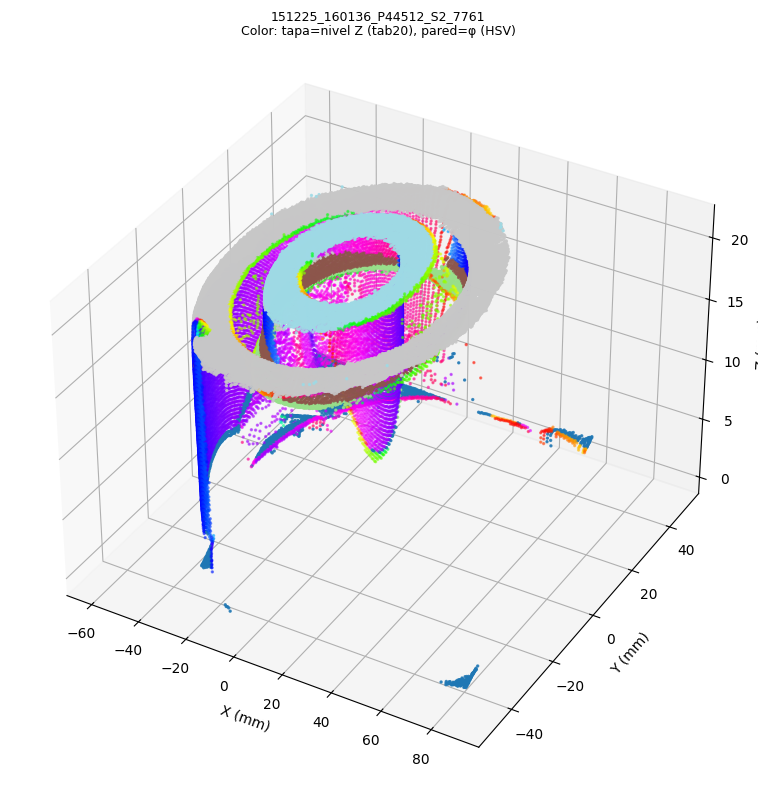

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# Submuestreo para no saturar el renderer
STEP = 4
rr, cc = np.where(valid[::STEP, ::STEP])
rr = rr * STEP;  cc = cc * STEP

x3 = X[rr, cc];  y3 = Y[rr, cc];  z3 = Z[rr, cc]

col3 = np.zeros((len(rr), 4))
for idx, (r, c) in enumerate(zip(rr, cc)):
    if flat_label_img[r, c] >= 0:
        k = flat_label_img[r, c]
        col3[idx] = colors_flat[k % len(colors_flat)]
        col3[idx, 3] = 0.8
    else:
        phi_v = float(phi[r, c])
        col3[idx] = plt.cm.hsv((phi_v + 180) / 360.0)
        col3[idx, 3] = 0.5

fig3d = plt.figure(figsize=(11, 8))
ax3d  = fig3d.add_subplot(1, 1, 1, projection='3d')
ax3d.scatter(x3, y3, z3, c=col3, s=2, depthshade=False)
ax3d.set_xlabel('X (mm)');  ax3d.set_ylabel('Y (mm)');  ax3d.set_zlabel('Z (mm)')
ax3d.set_title(f'{SAMPLE}\nColor: tapa=nivel Z (tab20), pared=φ (HSV)', fontsize=9)
ax3d.view_init(elev=35, azim=-60)
plt.tight_layout()
plt.show()


Polígonos de defecto: 1
Píxeles en máscara (original): 5489
Píxeles en máscara (erosión 5px): 4150
Fronteras en el entorno del defecto (5):
  (2, 15): circle  rms=0.29 px
  (3, 15): circle  rms=0.60 px
  (15, 16): circle  rms=6.59 px
  (2, 16): line  rms=0.16 px
  (3, 16): line  rms=1.56 px

Etiquetas de superficie: 5 caras planas + 16 sectores pared = 21 total
Píxeles etiquetados: 746268 / 746268 válidos


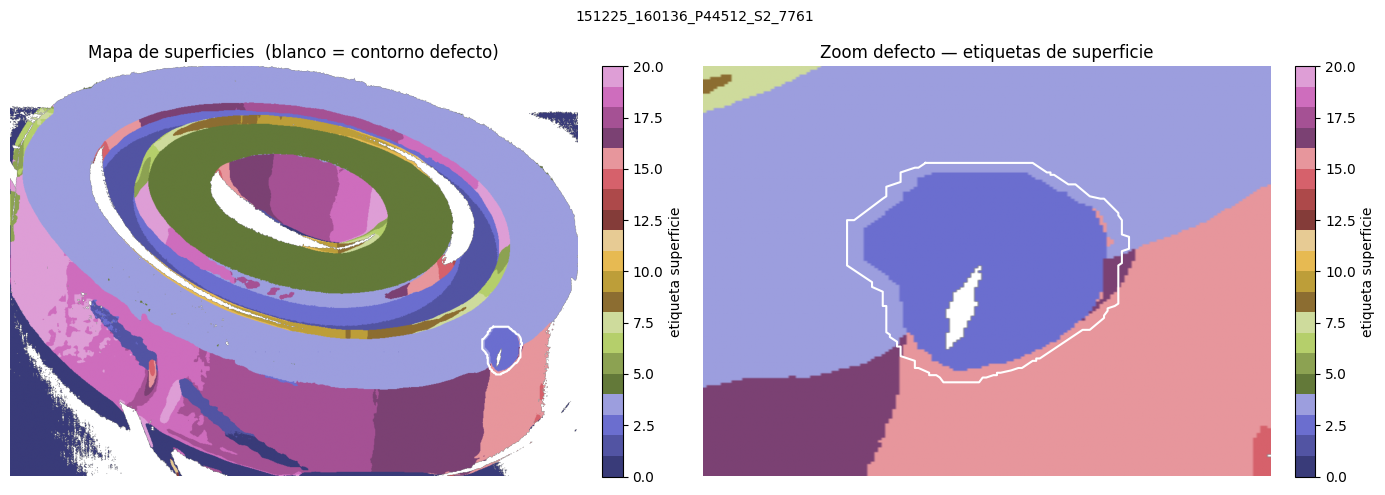

In [11]:
# ── 7a. Cargar máscara de defecto (YOLO) ─────────────────────────────────────
mask_path = f"{BASE}/rgb_seg/{SAMPLE}_rgb_seg.txt"

def load_yolo_seg_mask(txt_path, img_h, img_w):
    polygons = []
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    with open(txt_path, "r") as f:
        for line in f:
            vals = line.strip().split()
            if len(vals) < 5:
                continue
            coords = np.array(vals[1:], dtype=float).reshape(-1, 2)
            pts_px = (coords * np.array([img_w, img_h])).astype(np.int32)
            polygons.append(pts_px)
            cv2.fillPoly(mask, [pts_px], 1)
    return polygons, mask

polygons, defect_mask_raw = load_yolo_seg_mask(mask_path, H, W)

kernel_er = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*EROSION_PX+1, 2*EROSION_PX+1))
defect_mask = cv2.erode(defect_mask_raw, kernel_er)

print(f"Polígonos de defecto: {len(polygons)}")
print(f"Píxeles en máscara (original): {defect_mask_raw.sum()}")
print(f"Píxeles en máscara (erosión {EROSION_PX}px): {defect_mask.sum()}")

# ── 7b. Mapa unificado de etiquetas de superficie ─────────────────────────────
N_WALL_BINS = 16

phi_bin = ((phi + 180.0) / 360.0 * N_WALL_BINS).astype(int)
phi_bin = np.clip(phi_bin, 0, N_WALL_BINS - 1)

surf_label = np.full((H, W), -1, dtype=int)
surf_label[seg_flat] = flat_label_img[seg_flat]
surf_label[seg_wall] = K_flat + phi_bin[seg_wall]
K_surf = K_flat + N_WALL_BINS

# ── Extender fronteras al defecto: ajuste geométrico solo en el entorno ────────
# 1. Buscamos fronteras ÚNICAMENTE en el anillo exterior al defecto (zona sana).
# 2. Ajustamos línea o círculo a cada par de etiquetas adyacentes.
# 3. Clasificamos cada píxel del defecto según qué lado de la curva ocupa,
#    sin ningún BFS previo que pueda contaminar la asignación.

from collections import defaultdict as _defaultdict

_need_label  = valid & (surf_label < 0)
_defect_bool = defect_mask.astype(bool)

# Anillo de referencia: dilatar la máscara del defecto y quedarse fuera
_SEARCH_MM  = 10.0   # anchura del anillo de búsqueda de fronteras (mm)
_search_px  = int(round(_SEARCH_MM / pix_mm)) | 1
_ker_search = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (_search_px, _search_px))
_outer_srch = cv2.dilate(defect_mask, _ker_search).astype(bool)
# Solo píxeles sanos dentro del anillo
_search_zone = _outer_srch & ~_defect_bool & valid   # anillo sano exterior

# ── 1. Localizar transiciones entre etiquetas DENTRO del anillo sano ──────────
_bnd_pts = _defaultdict(list)

_sr_r, _sr_c = np.where(_search_zone)
# Conjunto rápido para saber si un pixel está en la zona de búsqueda
_sz_set = set(zip(_sr_r.tolist(), _sr_c.tolist()))

for r_, c_ in _sz_set:
    la = int(surf_label[r_, c_])
    if la < 0:
        continue
    for dr, dc in ((0, 1), (1, 0)):
        nr, nc = r_ + dr, c_ + dc
        if (nr, nc) not in _sz_set:
            continue
        lb = int(surf_label[nr, nc])
        if lb < 0 or lb == la:
            continue
        key = (min(la, lb), max(la, lb))
        _bnd_pts[key].append((c_ + dc * 0.5, r_ + dr * 0.5))  # (col, row)

# ── 2. Ajustar línea o círculo a cada frontera ─────────────────────────────────
def _fit_line(pts):
    mu = pts.mean(0)
    _, _, Vt = np.linalg.svd(pts - mu, full_matrices=False)
    n = Vt[1]; off = float(n @ mu)
    rms = float(np.sqrt(np.mean(((pts - mu) @ n) ** 2)))
    return dict(type='line', n=n, off=off, rms=rms)

def _fit_circle(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.column_stack([2 * x, 2 * y, np.ones(len(x))])
    try:
        sol = np.linalg.lstsq(A, x ** 2 + y ** 2, rcond=None)[0]
        cx, cy, c_ = sol
        r_ = float(np.sqrt(max(cx ** 2 + cy ** 2 + c_, 0.01)))
        rms = float(np.sqrt(np.mean((np.sqrt((x - cx) ** 2 + (y - cy) ** 2) - r_) ** 2)))
        return dict(type='circle', cx=cx, cy=cy, r=r_, rms=rms)
    except Exception:
        return dict(type='circle', rms=1e9)

def _sdf(bnd, cols, rows):
    c_, r_ = np.asarray(cols, float), np.asarray(rows, float)
    if bnd['type'] == 'line':
        return np.column_stack([c_, r_]) @ bnd['n'] - bnd['off']
    else:
        return np.sqrt((c_ - bnd['cx']) ** 2 + (r_ - bnd['cy']) ** 2) - bnd['r']

_fitted = {}
for key, pts_list in _bnd_pts.items():
    if len(pts_list) < 6:
        continue
    pts = np.array(pts_list)
    fl = _fit_line(pts)
    fc = _fit_circle(pts)
    _fitted[key] = fl if fl['rms'] <= fc['rms'] else fc

print(f"Fronteras en el entorno del defecto ({len(_fitted)}):")
for key, bnd in _fitted.items():
    print(f"  {key}: {bnd['type']}  rms={bnd['rms']:.2f} px")

# ── 3. Clasificar píxeles del defecto con la geometría extrapolada ─────────────
# Para cada frontera (la, lb) ajustada:
#   - Calibramos el signo con píxeles de referencia del entorno sano.
#   - Clasificamos los píxeles del defecto en la zona de influencia de esa frontera.
# Píxeles que no queden cubiertos por ninguna frontera reciben etiqueta por BFS.

_def_r, _def_c = np.where(_need_label)
_surf_ext = surf_label.copy()
_classified = np.zeros(len(_def_r), dtype=bool)

for (la, lb), bnd in _fitted.items():
    _mask_a = (surf_label == la) & _search_zone
    _mask_b = (surf_label == lb) & _search_zone
    _ra, _ca = np.where(_mask_a)
    _rb, _cb = np.where(_mask_b)
    if len(_ra) < 3 or len(_rb) < 3:
        continue
    _sda = float(np.median(_sdf(bnd, _ca.astype(float), _ra.astype(float))))
    _sdb = float(np.median(_sdf(bnd, _cb.astype(float), _rb.astype(float))))
    if np.sign(_sda) == np.sign(_sdb) or _sda == 0 or _sdb == 0:
        continue

    _lbl_pos = la if _sda > 0 else lb
    _lbl_neg = lb if _sda > 0 else la

    # Distancia de cada px de defecto a esta frontera
    _d_all = _sdf(bnd, _def_c.astype(float), _def_r.astype(float))

    # Zona de influencia: píxeles que están más cerca de esta frontera que de
    # cualquier otra (Voronoi implícito) — aquí simplificamos actuando sobre todos
    # los px no clasificados aún cuya etiqueta BFS sería la o lb.
    _new_lbl = np.where(_d_all >= 0, _lbl_pos, _lbl_neg)
    # Solo sobreescribir píxeles no clasificados aún
    _mask_act = ~_classified
    _surf_ext[_def_r[_mask_act], _def_c[_mask_act]] = _new_lbl[_mask_act]
    _classified[_mask_act] = True

# BFS fallback para píxeles sin frontera geométrica relevante
if (~_classified).any():
    from collections import deque as _deque
    _ker4   = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=np.uint8)
    _border = cv2.dilate(_need_label.astype(np.uint8), _ker4).astype(bool) & (surf_label >= 0)
    _sr, _sc = np.where(_border)
    _queue   = _deque(zip(_sr.tolist(), _sc.tolist()))
    while _queue:
        _r, _c = _queue.popleft()
        _lbl   = _surf_ext[_r, _c]
        for _dr, _dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            _nr, _nc = _r + _dr, _c + _dc
            if (0 <= _nr < H and 0 <= _nc < W
                    and _need_label[_nr, _nc] and _surf_ext[_nr, _nc] < 0):
                _surf_ext[_nr, _nc] = _lbl
                _queue.append((_nr, _nc))
    n_bfs = int((~_classified).sum())
    print(f"BFS fallback para {n_bfs} px sin frontera geométrica asignada")

surf_label[_need_label] = _surf_ext[_need_label]

print(f"\nEtiquetas de superficie: {K_flat} caras planas + {N_WALL_BINS} sectores pared = {K_surf} total")
print(f"Píxeles etiquetados: {(surf_label >= 0).sum()} / {valid.sum()} válidos")

# ── 7c. Mapa visual de etiquetas ──────────────────────────────────────────────
plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap_surf = plt.cm.tab20b
surf_disp = np.where(surf_label >= 0, surf_label, np.nan).astype(float)
im0 = axes[0].imshow(surf_disp, cmap=cmap_surf, aspect='auto',
                     vmin=0, vmax=K_surf - 1)
plt.colorbar(im0, ax=axes[0], label='etiqueta superficie', fraction=0.046, pad=0.04)
for pts in polygons:
    closed = np.vstack([pts, pts[0]])
    axes[0].plot(closed[:, 0], closed[:, 1], 'w-', lw=1.5)
axes[0].set_title('Mapa de superficies  (blanco = contorno defecto)')
axes[0].axis('off')

all_pts = np.vstack(polygons)
r0d = max(0, all_pts[:, 1].min() - 40);  r1d = min(H, all_pts[:, 1].max() + 40)
c0d = max(0, all_pts[:, 0].min() - 40);  c1d = min(W, all_pts[:, 0].max() + 40)
im1 = axes[1].imshow(surf_disp[r0d:r1d, c0d:c1d],
                     cmap=cmap_surf, aspect='auto', vmin=0, vmax=K_surf - 1)
plt.colorbar(im1, ax=axes[1], label='etiqueta superficie', fraction=0.046, pad=0.04)
for pts in polygons:
    pts_local = pts - np.array([c0d, r0d])
    closed = np.vstack([pts_local, pts_local[0]])
    axes[1].plot(closed[:, 0], closed[:, 1], 'w-', lw=1.5)
axes[1].set_title('Zoom defecto — etiquetas de superficie')
axes[1].axis('off')

plt.suptitle(SAMPLE, fontsize=10)
plt.tight_layout()
plt.show()


## 7b. Modelo paramétrico de la pieza — análisis geométrico

La pieza es un **sólido de revolución** compuesto por dos tipos de primitivas:

### Caras planas (tapas, escalones, alojamientos)
Cada cara plana corresponde a uno de los $K$ picos detectados en el histograma de $Z$.  
Se ajusta un plano $Z = a \cdot X + b \cdot Y + c$ por mínimos cuadrados sobre todos los píxeles de esa cara:

$$\mathbf{n} = (a, b, -1)^\top / \|(a,b,-1)\|, \quad Z_{\text{nom}} = a X + b Y + c$$

Las inclinaciones típicas ($|a|, |b| \lesssim 0.01\,\text{mm/mm}$) confirman que las caras son prácticamente horizontales.

### Paredes cilíndricas
Las paredes tienen normales radiales $\mathbf{N}_{xy} \propto (X - c_x,\, Y - c_y)$.  
Se ajusta un **cilindro circular** por mínimos cuadrados algebraicos:

$$2c_x X + 2c_y Y + c = X^2 + Y^2 \implies R = \sqrt{c_x^2 + c_y^2 + c}$$

La pieza tiene múltiples paredes coaxiales a distintos radios (engranaje), por lo que $R$ resume el radio dominante y se lista la distribución de radios para identificarlos.

### Perfil $r$–$Z$ (sólido de revolución)
El perfil mediana de $Z$ en función del radio $r = \sqrt{(X-c_x)^2+(Y-c_y)^2}$ caracteriza toda la geometría en una sola curva. Las zonas planas aparecen como bandas horizontales y las paredes como transiciones abruptas.

### Por qué `griddata` para Z_nom
El defecto está en la **transición entre dos caras a distinta altura** (≈17 mm y ≈19.8 mm) unidas por una pared. Ningún modelo suave (polinomio, perfil $r$–$Z$) puede representar ese escalón discontinuo: el mejor grado de polinomio explorado alcanza rms ≈ 1.07 mm frente a los 0.25 mm del `griddata` lineal desde el anillo exterior. La interpolación espacial respeta automáticamente las discontinuidades porque los puntos del anillo ya pertenecen a las distintas superficies.


── Planos de caras planas (píxeles globales fuera del defecto) ──
  Cara 0: Z = -0.01359·X -0.02819·Y + 2.1215 mm  rms=1.3845 mm  N=54073
  Cara 1: Z = +0.04166·X -0.00697·Y + 15.4133 mm  rms=1.3839 mm  N=34701
  Cara 2: Z = -0.00403·X -0.00006·Y + 16.7492 mm  rms=0.4835 mm  N=32745
  Cara 3: Z = -0.00308·X -0.00022·Y + 19.2690 mm  rms=0.2259 mm  N=239008
  Cara 4: Z = -0.00349·X +0.00167·Y + 20.5108 mm  rms=0.1290 mm  N=100626

── Cilindro global (todas las paredes) ──
  Centro: (-11.329, 3.013) mm
  Radio medio: 37.393 mm  rms=7.8645 mm
  (rms alto indica múltiples radios: paredes internas/externas)

  Distribución de radios en paredes:
    r≈10 mm: 22 px
    r≈15 mm: 213 px
    r≈20 mm: 220 px
    r≈25 mm: 1648 px
    r≈30 mm: 173 px
    r≈35 mm: 2376 px
    r≈40 mm: 3605 px


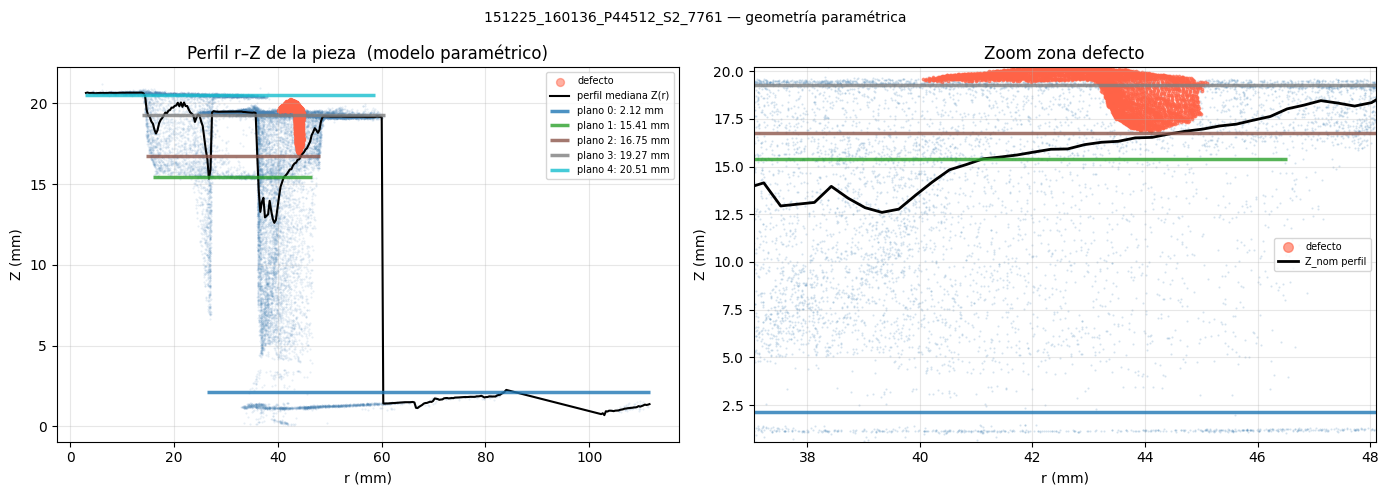

In [12]:
# ── Modelo nominal: análisis de la geometría de la pieza ─────────────────────
# Objetivo: entender la estructura paramétrica de la pieza para documentar
# las superficies que bordean el defecto y su geometría.
#
# Para el cálculo de Z_nom usamos griddata desde el anillo — único método que
# puede representar correctamente escalones discontinuos entre superficies.
# El "volumen paramétrico" queda caracterizado por los planos y cilindros
# ajustados a cada superficie identificada, aunque Z_nom se extrae del anillo.

# ── 1. Planos ajustados a las caras planas (modelo completo) ──────────────────
print("── Planos de caras planas (píxeles globales fuera del defecto) ──")
_nom_planes_global = {}
for k in range(K_flat):
    mask_k = (flat_label_img == k) & valid & ~defect_mask.astype(bool)
    n_k = int(mask_k.sum())
    if n_k < 20:
        continue
    Xk = X[mask_k].astype(float);  Yk = Y[mask_k].astype(float)
    Zk = Z[mask_k].astype(float)
    # Submuestreo para eficiencia con N grande
    if n_k > 5000:
        rng = np.random.default_rng(42)
        idx_sub = rng.choice(n_k, 5000, replace=False)
        Xk, Yk, Zk = Xk[idx_sub], Yk[idx_sub], Zk[idx_sub]
    A   = np.column_stack([Xk, Yk, np.ones(len(Xk))])
    sol = np.linalg.lstsq(A, Zk, rcond=None)[0]
    rms = float(np.sqrt(np.mean((Zk - A @ sol)**2)))
    _nom_planes_global[k] = sol
    print(f"  Cara {k}: Z = {sol[0]:+.5f}·X {sol[1]:+.5f}·Y + {sol[2]:.4f} mm  "
          f"rms={rms:.4f} mm  N={n_k}")

# ── 2. Cilindro global de las paredes ─────────────────────────────────────────
_wall_valid = seg_wall & valid & ~defect_mask.astype(bool)
_Xw = X[_wall_valid].astype(float);  _Yw = Y[_wall_valid].astype(float)
rng_cyl = np.random.default_rng(42)
_idx_cyl = rng_cyl.choice(len(_Xw), min(10000, len(_Xw)), replace=False)
_Xws, _Yws = _Xw[_idx_cyl], _Yw[_idx_cyl]
_Aw = np.column_stack([2*_Xws, 2*_Yws, np.ones(len(_Xws))])
_sol_cyl = np.linalg.lstsq(_Aw, _Xws**2 + _Yws**2, rcond=None)[0]
_cx_cyl, _cy_cyl, _c_cyl = _sol_cyl
_R_cyl = float(np.sqrt(max(_cx_cyl**2 + _cy_cyl**2 + _c_cyl, 0.01)))
_r_wall_all = np.sqrt((_Xws - _cx_cyl)**2 + (_Yws - _cy_cyl)**2)
print(f"\n── Cilindro global (todas las paredes) ──")
print(f"  Centro: ({_cx_cyl:.3f}, {_cy_cyl:.3f}) mm")
print(f"  Radio medio: {_R_cyl:.3f} mm  rms={np.sqrt(np.mean((_r_wall_all-_R_cyl)**2)):.4f} mm")
print(f"  (rms alto indica múltiples radios: paredes internas/externas)")

# Radios por sector φ
_phi_w = np.degrees(np.arctan2(_Yw[_idx_cyl] - _cy_cyl, _Xws - _cx_cyl))
print(f"\n  Distribución de radios en paredes:")
for _r_bin in np.arange(0, _R_cyl + 5, 5):
    _mb = np.abs(_r_wall_all - _r_bin) < 2.5
    if _mb.sum() > 20:
        print(f"    r≈{_r_bin:.0f} mm: {_mb.sum()} px")

# ── 3. Perfil r–Z: visualización de la geometría de la pieza ──────────────────
_ref_mask_v = valid & ~defect_mask.astype(bool)
_r_all_v = np.sqrt((X[_ref_mask_v] - _cx_cyl)**2 + (Y[_ref_mask_v] - _cy_cyl)**2)
_z_all_v = Z[_ref_mask_v].astype(float)
_R_BIN = 0.3
_re = np.arange(_r_all_v.min(), _r_all_v.max() + _R_BIN, _R_BIN)
_rc_bins = (_re[:-1] + _re[1:]) / 2
_z_med_p = np.array([np.median(_z_all_v[(_r_all_v >= _re[i]) & (_r_all_v < _re[i+1])])
                     if ((_r_all_v >= _re[i]) & (_r_all_v < _re[i+1])).sum() >= 3
                     else np.nan for i in range(len(_rc_bins))])

_def_b  = defect_mask.astype(bool) & valid
_r_def  = np.sqrt((X[_def_b] - _cx_cyl)**2 + (Y[_def_b] - _cy_cyl)**2)
_z_def  = Z[_def_b].astype(float)

plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rng_v = np.random.default_rng(0)
idx_v = rng_v.choice(len(_r_all_v), min(20000, len(_r_all_v)), replace=False)
axes[0].scatter(_r_all_v[idx_v], _z_all_v[idx_v], s=0.2, alpha=0.15, c='steelblue')
axes[0].scatter(_r_def, _z_def, s=2, alpha=0.5, c='tomato', label='defecto')
_vp2 = np.isfinite(_z_med_p)
axes[0].plot(_rc_bins[_vp2], _z_med_p[_vp2], 'k-', lw=1.5, label='perfil mediana Z(r)')
# Marcar caras planas ajustadas
colors_v = plt.cm.tab10(np.linspace(0, 1, K_flat))
for k, sol in _nom_planes_global.items():
    mask_k = (flat_label_img == k) & valid & ~defect_mask.astype(bool)
    r_k = np.sqrt((X[mask_k] - _cx_cyl)**2 + (Y[mask_k] - _cy_cyl)**2)
    axes[0].hlines(float(sol[2]), float(r_k.min()), float(r_k.max()),
                   colors=colors_v[k], lw=2.5, alpha=0.8, label=f'plano {k}: {sol[2]:.2f} mm')
axes[0].set_xlabel('r (mm)');  axes[0].set_ylabel('Z (mm)')
axes[0].set_title('Perfil r–Z de la pieza  (modelo paramétrico)')
axes[0].legend(fontsize=7, markerscale=4);  axes[0].grid(alpha=0.3)

# Zoom sobre la zona del defecto
_r_zoom = (_r_def.min() - 3, _r_def.max() + 3)
_z_zoom_data = np.concatenate([_z_def, _z_all_v[(_r_all_v >= _r_zoom[0]) & (_r_all_v <= _r_zoom[1])]])
_z_zoom = (float(np.percentile(_z_zoom_data, 1)) - 0.5, float(np.percentile(_z_zoom_data, 99)) + 0.5)
axes[1].scatter(_r_all_v[idx_v], _z_all_v[idx_v], s=0.3, alpha=0.2, c='steelblue')
axes[1].scatter(_r_def, _z_def, s=3, alpha=0.6, c='tomato', label='defecto')
axes[1].plot(_rc_bins[_vp2], _z_med_p[_vp2], 'k-', lw=2, label='Z_nom perfil')
for k, sol in _nom_planes_global.items():
    mask_k = (flat_label_img == k) & valid & ~defect_mask.astype(bool)
    r_k = np.sqrt((X[mask_k] - _cx_cyl)**2 + (Y[mask_k] - _cy_cyl)**2)
    axes[1].hlines(float(sol[2]), float(r_k.min()), float(r_k.max()),
                   colors=colors_v[k], lw=2.5, alpha=0.8)
axes[1].set_xlim(*_r_zoom);  axes[1].set_ylim(*_z_zoom)
axes[1].set_xlabel('r (mm)');  axes[1].set_ylabel('Z (mm)')
axes[1].set_title('Zoom zona defecto')
axes[1].legend(fontsize=7, markerscale=4);  axes[1].grid(alpha=0.3)

plt.suptitle(f'{SAMPLE} — geometría paramétrica', fontsize=10)
plt.tight_layout()
plt.show()


Anillo: 8.0 mm → 63 px  |  10574 px
Z_diff: min=-0.4504  max=0.6024  std=0.2516 mm  N=3987


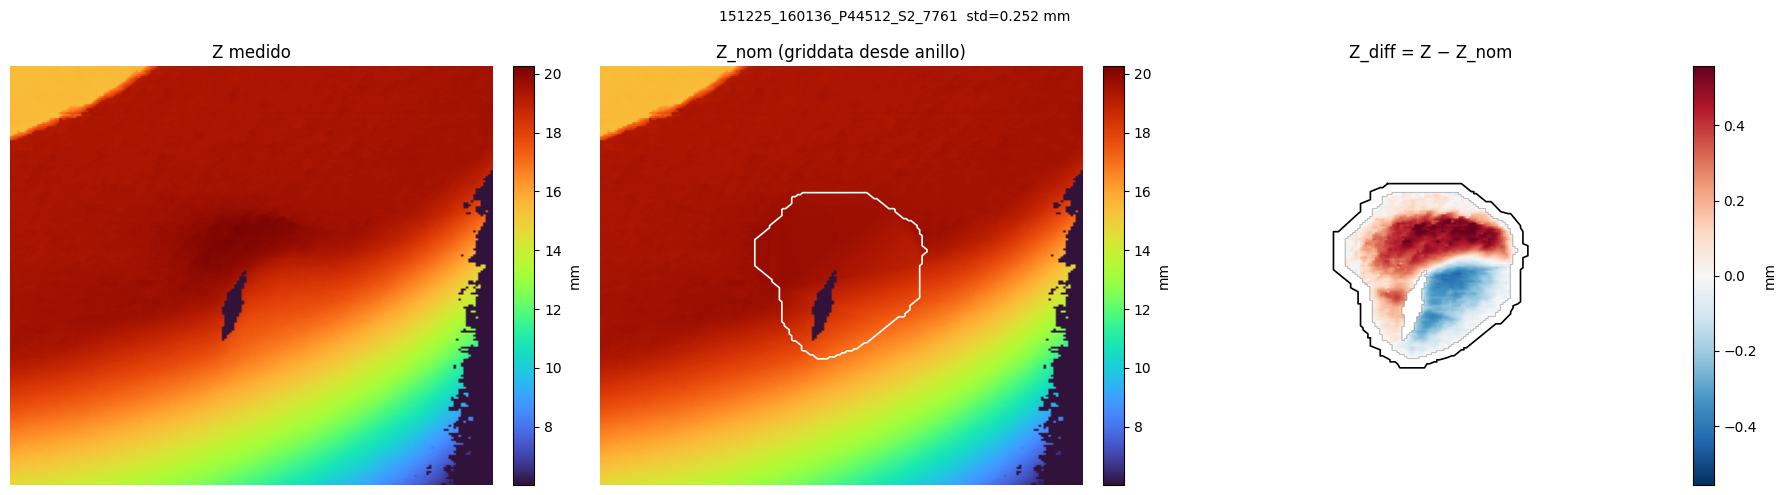

In [13]:
# ── Z_nom por griddata desde el anillo ──────────────────────────────────────
# Para geometrías con escalones (caras a distintos niveles Z conectadas por paredes),
# la interpolación espacial desde el anillo exterior es el método más correcto:
# respeta automáticamente las discontinuidades y no requiere propagación de etiquetas.
from scipy.interpolate import griddata as _griddata

RING_MM = 8.0
ring_px = int(round(RING_MM / pix_mm)) | 1
ker_ring = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ring_px, ring_px))
outer    = cv2.dilate(defect_mask, ker_ring).astype(bool)
ring_mask = outer & ~defect_mask.astype(bool) & valid

print(f"Anillo: {RING_MM} mm → {ring_px} px  |  {ring_mask.sum()} px")

r_ring, c_ring = np.where(ring_mask)
z_ring = Z[r_ring, c_ring].astype(float)
src_pts = np.column_stack([c_ring.astype(float), r_ring.astype(float)])

r_def, c_def = np.where(defect_mask.astype(bool) & valid)
dst_pts = np.column_stack([c_def.astype(float), r_def.astype(float)])

z_interp = _griddata(src_pts, z_ring, dst_pts, method='linear')
nan_m = np.isnan(z_interp)
if nan_m.any():
    z_near = _griddata(src_pts, z_ring, dst_pts[nan_m], method='nearest')
    z_interp[nan_m] = z_near
    print(f"  Fallback nearest para {nan_m.sum()} px")

Z_nom = Z.copy().astype(float)
Z_nom[r_def, c_def] = z_interp

# ── Z_diff ────────────────────────────────────────────────────────────────────
Z_diff = np.where(valid & defect_mask.astype(bool), Z.astype(float) - Z_nom, np.nan)

z_def_vals = Z_diff[defect_mask.astype(bool) & valid]
z_def_vals = z_def_vals[np.isfinite(z_def_vals)]
print(f"Z_diff: min={np.nanmin(z_def_vals):.4f}  max={np.nanmax(z_def_vals):.4f}  "
      f"std={np.nanstd(z_def_vals):.4f} mm  N={len(z_def_vals)}")

# ── Visualización ─────────────────────────────────────────────────────────────
r0v = max(0, r_def.min() - ring_px);  r1v = min(H, r_def.max() + ring_px + 1)
c0v = max(0, c_def.min() - ring_px);  c1v = min(W, c_def.max() + ring_px + 1)

def _crop(a): return a[r0v:r1v, c0v:c1v]

Z_cr     = _crop(Z.astype(float))
Z_nom_cr = _crop(Z_nom)
Zd_cr    = _crop(Z_diff)
msk_cr   = _crop(defect_mask.astype(bool))
vld_cr   = _crop(valid)

vmin_z = float(np.nanmin(Z_cr[vld_cr]));  vmax_z = float(np.nanmax(Z_cr[vld_cr]))
vmax_d = float(np.nanpercentile(np.abs(z_def_vals), 99))

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(Z_cr, cmap='turbo', aspect='auto', vmin=vmin_z, vmax=vmax_z)
plt.colorbar(im0, ax=axes[0], label='mm', fraction=0.046, pad=0.04)
axes[0].set_title('Z medido'); axes[0].axis('off')

im1 = axes[1].imshow(Z_nom_cr, cmap='turbo', aspect='auto', vmin=vmin_z, vmax=vmax_z)
plt.colorbar(im1, ax=axes[1], label='mm', fraction=0.046, pad=0.04)
axes[1].contour(msk_cr, levels=[0.5], colors='white', linewidths=1.2)
axes[1].set_title('Z_nom (griddata desde anillo)'); axes[1].axis('off')

im2 = axes[2].imshow(Zd_cr, cmap='RdBu_r', aspect='auto', vmin=-vmax_d, vmax=vmax_d)
plt.colorbar(im2, ax=axes[2], label='mm', fraction=0.046, pad=0.04)
for pts in polygons:
    pts_l = np.vstack([pts, pts[0]]) - np.array([c0v, r0v])
    axes[2].plot(pts_l[:, 0], pts_l[:, 1], 'k-', lw=1.2)
axes[2].set_title('Z_diff = Z − Z_nom'); axes[2].axis('off')

plt.suptitle(f'{SAMPLE}  std={z_def_vals.std():.3f} mm', fontsize=10)
plt.tight_layout()
plt.show()


## 8. Multi-Splat: ajuste gaussiano sobre Z_diff

In [14]:
import time as _time
from scipy.optimize import least_squares
from scipy.ndimage import distance_transform_edt

# ── Funciones gaussianas ──────────────────────────────────────────────────────
def gauss2d_rotated(params, x, y):
    A, x0, y0, sx, sy, th = params
    c, s = np.cos(th), np.sin(th)
    u =  (x - x0) * c + (y - y0) * s
    v = -(x - x0) * s + (y - y0) * c
    return A * np.exp(-0.5 * (u**2 / sx**2 + v**2 / sy**2))

def gauss_mixture(params, x, y):
    K = len(params) // 6
    return sum(gauss2d_rotated(params[6*k:6*k+6], x, y) for k in range(K))

def gauss_mixture_and_jac(params, x, y):
    K = len(params) // 6; N = len(x)
    out = np.zeros(N); J = np.zeros((N, 6*K))
    for k in range(K):
        A, x0, y0, sx, sy, th = params[6*k:6*k+6]
        c, s = np.cos(th), np.sin(th)
        dx = x - x0; dy = y - y0
        u = dx*c + dy*s; v = -dx*s + dy*c
        eu2 = u**2/sx**2; ev2 = v**2/sy**2
        g = A * np.exp(-0.5*(eu2+ev2))
        out += g
        J[:, 6*k]   = g / A
        J[:, 6*k+1] = g * (u*c/sx**2 - v*s/sy**2)
        J[:, 6*k+2] = g * (u*s/sx**2 + v*c/sy**2)
        J[:, 6*k+3] = g * eu2 / sx
        J[:, 6*k+4] = g * ev2 / sy
        J[:, 6*k+5] = g * u*v*(1/sx**2 - 1/sy**2)
    return out, J

def volume_mixture(params):
    K = len(params) // 6
    return sum(params[6*k] * 2*np.pi * params[6*k+3] * params[6*k+4] for k in range(K))

# ── Parámetros ────────────────────────────────────────────────────────────────
K_MAX         = 12
WIN_DEFECT_MM = 4.0
WIN_DEFECT_PX = int(round(WIN_DEFECT_MM / pix_mm)) | 1

mask_def_valid = defect_mask.astype(bool) & valid
rows_def_s, cols_def_s = np.where(mask_def_valid)

X_MIN = float(cols_def_s.min()) * pix_mm;  X_MAX = float(cols_def_s.max()) * pix_mm
Y_MIN = float(rows_def_s.min()) * pix_mm;  Y_MAX = float(rows_def_s.max()) * pix_mm
SIG_LONG = (X_MAX - X_MIN) / 2;  SIG_SHORT = (Y_MAX - Y_MIN) / 2

x_obs = cols_def_s.astype(np.float64) * pix_mm
y_obs = rows_def_s.astype(np.float64) * pix_mm

# Distancia a la máscara (para penalizar centros fuera)
dist_px = distance_transform_edt(~mask_def_valid).astype(np.float32)
grad_r_d, grad_c_d = np.gradient(dist_px.astype(np.float64))

# SG 2D para inicialización local
def sg2d_local(Z_in, win):
    hw = win // 2
    yi, xi = np.mgrid[-hw:hw+1, -hw:hw+1]
    reg = np.stack([xi**2, yi**2, xi*yi, xi, yi, np.ones_like(xi)], axis=-1)
    A_m = reg.reshape(-1, 6)
    P   = np.linalg.inv(A_m.T @ A_m) @ A_m.T
    ks  = P.reshape(6, win, win)
    return np.stack([cv2.filter2D(Z_in.astype(np.float64), -1, k,
                                   borderType=cv2.BORDER_REFLECT) for k in ks], axis=-1)

def run_multisplat(Z_source, label, lambda_pen=5.0):
    z_obs_ = np.clip(Z_source[rows_def_s, cols_def_s].astype(np.float64), 0.0, None)
    N_obs  = len(z_obs_)
    N_sub  = min(2000, N_obs)
    rng    = np.random.default_rng(7)
    idx_s  = rng.choice(N_obs, N_sub, replace=False)
    xs, ys, zs = x_obs[idx_s], y_obs[idx_s], z_obs_[idx_s]

    A_max = max(float(z_obs_.max()) * 3.0, 0.1)
    blo = [0, X_MIN, Y_MIN, 0.15, 0.15, -np.pi/2]
    bhi = [A_max, X_MAX, Y_MAX, SIG_LONG, SIG_SHORT, np.pi/2]

    coefs_ph = sg2d_local(
        np.where(np.isfinite(Z_source), np.clip(Z_source, 0, None), 0.0),
        WIN_DEFECT_PX)
    coefs_ph_scaled = np.stack([
        coefs_ph[..., 0]/pix_mm**2, coefs_ph[..., 1]/pix_mm**2,
        coefs_ph[..., 2]/pix_mm**2, coefs_ph[..., 3]/pix_mm,
        coefs_ph[..., 4]/pix_mm,    coefs_ph[..., 5]], axis=-1)

    res_all = {}; p_cur = []
    print(f'\n── {label} ──')
    t0 = _time.perf_counter()

    for K in range(1, K_MAX + 1):
        prev = gauss_mixture(p_cur, x_obs, y_obs) if p_cur else np.zeros(N_obs)
        resid = np.clip(z_obs_ - prev, 0, None)
        res_img = np.zeros_like(Z_source)
        res_img[rows_def_s, cols_def_s] = resid
        f_ws = np.where(mask_def_valid, res_img, -np.inf)
        pr, pc = np.unravel_index(np.argmax(f_ws), f_ws.shape)
        mX = float(pc) * pix_mm;  mY = float(pr) * pix_mm

        a0, b0, c0_, d0, e0, f0 = coefs_ph_scaled[pr, pc]
        Hm = np.array([[2*a0, c0_], [c0_, 2*b0]])
        try:
            dlt = -np.linalg.solve(Hm, [d0, e0])
            mX = float(np.clip(mX+dlt[0], blo[1]+1e-6, bhi[1]-1e-6))
            mY = float(np.clip(mY+dlt[1], blo[2]+1e-6, bhi[2]-1e-6))
            A0 = float(np.clip(f0, blo[0]+1e-6, bhi[0]-1e-6))
            Sm = -A0*np.linalg.inv(Hm) if A0 > 1e-6 else None
            if Sm is not None:
                ev_, evec_ = np.linalg.eigh(Sm)
                ord_ = np.argsort(ev_)[::-1]
                sx_ = float(np.clip(np.sqrt(abs(ev_[ord_[0]])), blo[3]+1e-6, bhi[3]-1e-6))
                sy_ = float(np.clip(np.sqrt(abs(ev_[ord_[1]])), blo[4]+1e-6, bhi[4]-1e-6))
                th_ = float(np.arctan2(evec_[1,ord_[0]], evec_[0,ord_[0]]))
            else:
                sx_, sy_, th_ = SIG_LONG*0.3, SIG_SHORT*0.4, 0.0
        except Exception:
            A0 = float(np.clip(res_img[pr,pc], blo[0]+1e-6, bhi[0]-1e-6))
            sx_, sy_, th_ = SIG_LONG*0.3, SIG_SHORT*0.4, 0.0

        p_new = [float(np.clip(v, lo+1e-6, hi-1e-6))
                 for v, lo, hi in zip([A0, mX, mY, sx_, sy_, th_], blo, bhi)]
        p0 = p_cur + p_new

        # Residuos + penalización por centro fuera de máscara
        cf_state = {}
        def fun(p):
            p = np.asarray(p)
            if not np.array_equal(p, cf_state.get('p')):
                fv, jv = gauss_mixture_and_jac(p, xs, ys)
                cf_state.update(p=p.copy(), r=fv-zs, j=jv)
            K_ = len(p)//6
            pen = np.zeros(K_); Jp = np.zeros((K_, len(p)))
            for k_ in range(K_):
                ci_ = int(np.clip(p[6*k_+1]/pix_mm, 0, W-1))
                ri_ = int(np.clip(p[6*k_+2]/pix_mm, 0, H-1))
                d_ = float(dist_px[ri_, ci_]) * pix_mm
                if d_ > 0:
                    pen[k_] = lambda_pen * d_
                    Jp[k_, 6*k_+1] = lambda_pen * float(grad_c_d[ri_, ci_])
                    Jp[k_, 6*k_+2] = lambda_pen * float(grad_r_d[ri_, ci_])
            return np.concatenate([cf_state['r'], pen])

        def jac(p):
            p = np.asarray(p)
            if not np.array_equal(p, cf_state.get('p')):
                fv, jv = gauss_mixture_and_jac(p, xs, ys)
                cf_state.update(p=p.copy(), r=fv-zs, j=jv)
            K_ = len(p)//6
            pen = np.zeros(K_); Jp = np.zeros((K_, len(p)))
            for k_ in range(K_):
                ci_ = int(np.clip(p[6*k_+1]/pix_mm, 0, W-1))
                ri_ = int(np.clip(p[6*k_+2]/pix_mm, 0, H-1))
                d_ = float(dist_px[ri_, ci_]) * pix_mm
                if d_ > 0:
                    Jp[k_, 6*k_+1] = lambda_pen * float(grad_c_d[ri_, ci_])
                    Jp[k_, 6*k_+2] = lambda_pen * float(grad_r_d[ri_, ci_])
            return np.vstack([cf_state['j'], Jp])

        rK = least_squares(fun, p0, jac=jac, bounds=(blo*K, bhi*K),
                           method='trf', xtol=1e-9, ftol=1e-9, gtol=1e-9,
                           max_nfev=20_000)
        p_cur = list(rK.x)
        V_K = volume_mixture(p_cur)
        t_K = _time.perf_counter() - t0
        res_all[K] = dict(params=p_cur.copy(), V=V_K, nfev=rK.nfev, t=t_K)
        print(f'  K={K}: V={V_K:.4f} mm³  nfev={rK.nfev}  t={t_K*1000:.0f}ms')

    return res_all

Z_diff_clean = np.nan_to_num(Z_diff, nan=0.0)

print('=== LADO POSITIVO (protuberancias) ===')
results_pos = run_multisplat(Z_diff_clean,  'lado positivo')
print('\n=== LADO NEGATIVO (hundimientos) ===')
results_neg = run_multisplat(-Z_diff_clean, 'lado negativo')


=== LADO POSITIVO (protuberancias) ===

── lado positivo ──
  K=1: V=11.2552 mm³  nfev=17  t=5ms
  K=2: V=13.4782 mm³  nfev=17  t=10ms
  K=3: V=16.3650 mm³  nfev=15  t=17ms
  K=4: V=16.2968 mm³  nfev=15  t=27ms
  K=5: V=17.8172 mm³  nfev=15  t=38ms
  K=6: V=11.3150 mm³  nfev=22  t=87ms
  K=7: V=10.7264 mm³  nfev=41  t=284ms
  K=8: V=10.6102 mm³  nfev=21  t=379ms
  K=9: V=10.6916 mm³  nfev=21  t=540ms
  K=10: V=10.6457 mm³  nfev=28  t=746ms
  K=11: V=10.6515 mm³  nfev=34  t=1078ms
  K=12: V=10.6284 mm³  nfev=23  t=1244ms

=== LADO NEGATIVO (hundimientos) ===

── lado negativo ──
  K=1: V=4.4911 mm³  nfev=16  t=4ms
  K=2: V=4.6858 mm³  nfev=17  t=10ms
  K=3: V=4.7231 mm³  nfev=20  t=22ms
  K=4: V=4.4099 mm³  nfev=25  t=51ms
  K=5: V=4.4758 mm³  nfev=17  t=89ms
  K=6: V=4.5421 mm³  nfev=19  t=119ms
  K=7: V=4.3612 mm³  nfev=20  t=167ms
  K=8: V=4.6892 mm³  nfev=16  t=436ms
  K=9: V=4.5061 mm³  nfev=27  t=675ms
  K=10: V=4.5343 mm³  nfev=27  t=807ms
  K=11: V=4.3982 mm³  nfev=20  t=981ms
 

POSITIVO: K=12  V+ = +10.6284 mm³
NEGATIVO: K=12  V− = −4.6430 mm³
Neto: +5.9855 mm³


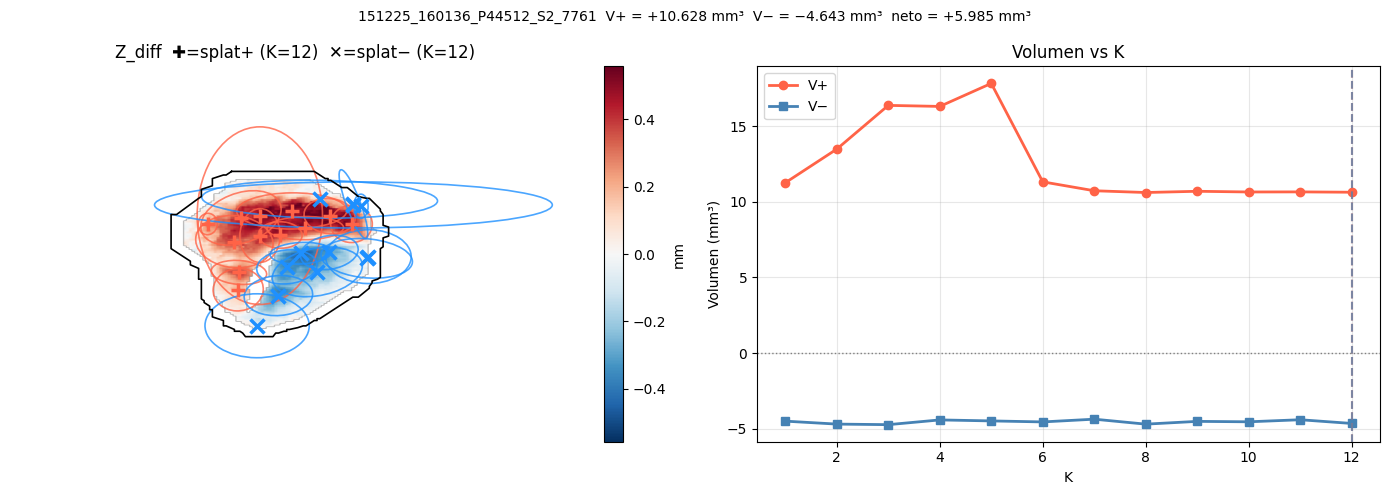

In [15]:
# ── Selección de K óptimo por BIC ────────────────────────────────────────────
def bic_for(results_dict, sign=1):
    z_obs_ = np.clip(sign * Z_diff_clean[rows_def_s, cols_def_s], 0, None)
    K_vals_ = sorted(results_dict.keys())
    bics = [np.sum((z_obs_ - gauss_mixture(results_dict[k]['params'], x_obs, y_obs))**2)
            + 6*k * float(np.var(z_obs_)) for k in K_vals_]
    return bics, K_vals_[int(np.argmin(bics))]

K_vals = sorted(results_pos.keys())
bic_pos, K_best_pos = bic_for(results_pos,  +1)
bic_neg, K_best_neg = bic_for(results_neg,  -1)

V_pos = results_pos[K_best_pos]['V']
V_neg = results_neg[K_best_neg]['V']
p_best_pos = results_pos[K_best_pos]['params']
p_best_neg = results_neg[K_best_neg]['params']

print(f'POSITIVO: K={K_best_pos}  V+ = +{V_pos:.4f} mm³')
print(f'NEGATIVO: K={K_best_neg}  V− = −{V_neg:.4f} mm³')
print(f'Neto: {V_pos - V_neg:+.4f} mm³')

# ── Visualización: Z_diff + centros de splats ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vmax_d2 = float(np.nanpercentile(np.abs(z_def_vals), 99))
im0 = axes[0].imshow(Zd_cr, cmap='RdBu_r', aspect='auto', vmin=-vmax_d2, vmax=vmax_d2)
plt.colorbar(im0, ax=axes[0], label='mm', fraction=0.046, pad=0.04)
for pts in polygons:
    pts_l = np.vstack([pts, pts[0]]) - np.array([c0v, r0v])
    axes[0].plot(pts_l[:, 0], pts_l[:, 1], 'k-', lw=1.2)
for j in range(len(p_best_pos)//6):
    cx = p_best_pos[6*j+1]/pix_mm - c0v
    cy = p_best_pos[6*j+2]/pix_mm - r0v
    sx = p_best_pos[6*j+3]/pix_mm;  sy = p_best_pos[6*j+4]/pix_mm
    axes[0].plot(cx, cy, '+', color='tomato', ms=10, mew=2.5)
    axes[0].add_patch(mpatches.Ellipse((cx, cy), 4*sx, 4*sy,
        angle=np.degrees(p_best_pos[6*j+5]), fill=False,
        edgecolor='tomato', lw=1.2, alpha=0.8))
for j in range(len(p_best_neg)//6):
    cx = p_best_neg[6*j+1]/pix_mm - c0v
    cy = p_best_neg[6*j+2]/pix_mm - r0v
    sx = p_best_neg[6*j+3]/pix_mm;  sy = p_best_neg[6*j+4]/pix_mm
    axes[0].plot(cx, cy, 'x', color='dodgerblue', ms=10, mew=2.5)
    axes[0].add_patch(mpatches.Ellipse((cx, cy), 4*sx, 4*sy,
        angle=np.degrees(p_best_neg[6*j+5]), fill=False,
        edgecolor='dodgerblue', lw=1.2, alpha=0.8))
axes[0].set_title(f'Z_diff  ✚=splat+ (K={K_best_pos})  ✕=splat− (K={K_best_neg})')
axes[0].axis('off')

# V vs K
axes[1].plot(K_vals, [results_pos[k]['V'] for k in K_vals], 'o-', color='tomato', lw=2, label='V+')
axes[1].plot(K_vals, [-results_neg[k]['V'] for k in K_vals], 's-', color='steelblue', lw=2, label='V−')
axes[1].axvline(K_best_pos, color='tomato',    lw=1.5, ls='--', alpha=0.7)
axes[1].axvline(K_best_neg, color='steelblue', lw=1.5, ls='--', alpha=0.7)
axes[1].axhline(0, color='gray', lw=1, ls=':')
axes[1].set_xlabel('K');  axes[1].set_ylabel('Volumen (mm³)')
axes[1].set_title('Volumen vs K');  axes[1].legend();  axes[1].grid(alpha=0.3)

plt.suptitle(f'{SAMPLE}  V+ = +{V_pos:.3f} mm³  V− = −{V_neg:.3f} mm³  neto = {V_pos-V_neg:+.3f} mm³',
             fontsize=10)
plt.tight_layout()
plt.show()


══ Métricas del defecto ══
  Largo total   : 10.352 mm  (semieje 5.176 mm)
  Ancho total   : 8.645 mm  (semieje 4.322 mm)
  Ángulo eje 1  : 101.8°
  Altura máx (+): 0.5910 mm
  Prof. máx  (−): 0.4536 mm
  Rel. L/A      : 1.20
  V+  sobrante  : +10.6284 mm³
  V−  faltante  : −4.6430 mm³
  V neto        : +5.9855 mm³


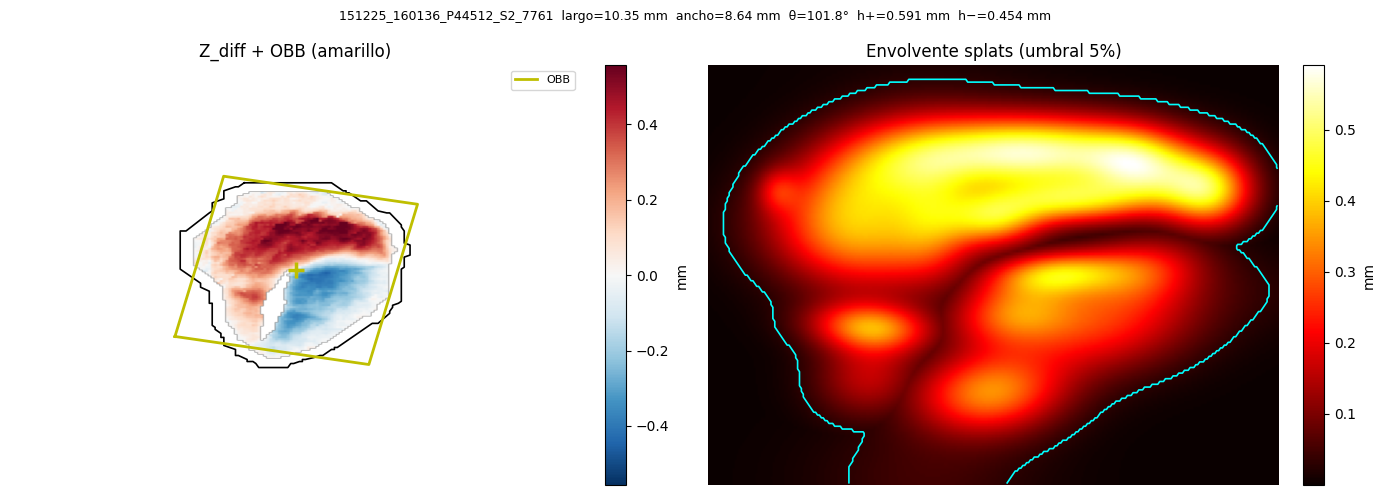

In [16]:
# ── Métricas geométricas del defecto (OBB por PCA sobre envolvente splats) ────
nc_m, nr_m = 300, 150
c_m = np.linspace(float(cols_def_s.min()), float(cols_def_s.max()), nc_m)
r_m = np.linspace(float(rows_def_s.min()), float(rows_def_s.max()), nr_m)
CM, RM = np.meshgrid(c_m, r_m)
xm = CM * pix_mm;  ym = RM * pix_mm

Z_spl_pos = gauss_mixture(p_best_pos, xm.ravel(), ym.ravel()).reshape(nr_m, nc_m)
Z_spl_neg = gauss_mixture(p_best_neg, xm.ravel(), ym.ravel()).reshape(nr_m, nc_m)

h_max =  float(Z_spl_pos.max())
h_min = -float(Z_spl_neg.max())

THR_FRAC    = 0.05
Z_envelope  = np.maximum(Z_spl_pos, Z_spl_neg)
mask_active = Z_envelope > THR_FRAC * float(Z_envelope.max())

if mask_active.any():
    r_act, c_act = np.where(mask_active)
    pts_mm = np.column_stack([xm[r_act, c_act], ym[r_act, c_act]])
    mu  = pts_mm.mean(axis=0)
    cov = np.cov((pts_mm - mu).T)
    eig_vals, eig_vecs = np.linalg.eigh(cov)
    order    = np.argsort(eig_vals)[::-1]
    eig_vecs = eig_vecs[:, order]
    proj     = (pts_mm - mu) @ eig_vecs
    semieje_largo = float((proj[:,0].max() - proj[:,0].min()) / 2)
    semieje_ancho = float((proj[:,1].max() - proj[:,1].min()) / 2)
    largo, ancho  = 2*semieje_largo, 2*semieje_ancho
    ang_deg = float(np.degrees(np.arctan2(eig_vecs[1,0], eig_vecs[0,0])))
else:
    largo = ancho = semieje_largo = semieje_ancho = ang_deg = 0.0
    mu = np.zeros(2);  eig_vecs = np.eye(2)

print("══ Métricas del defecto ══")
print(f"  Largo total   : {largo:.3f} mm  (semieje {semieje_largo:.3f} mm)")
print(f"  Ancho total   : {ancho:.3f} mm  (semieje {semieje_ancho:.3f} mm)")
print(f"  Ángulo eje 1  : {ang_deg:.1f}°")
print(f"  Altura máx (+): {h_max:.4f} mm")
print(f"  Prof. máx  (−): {abs(h_min):.4f} mm")
print(f"  Rel. L/A      : {largo/ancho:.2f}" if ancho > 0 else "  Rel. L/A: N/A")
print(f"  V+  sobrante  : +{V_pos:.4f} mm³")
print(f"  V−  faltante  : −{V_neg:.4f} mm³")
print(f"  V neto        : {V_pos - V_neg:+.4f} mm³")

# ── Figura: envolvente + OBB ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Z_diff con OBB superpuesta
im0 = axes[0].imshow(Zd_cr, cmap='RdBu_r', aspect='auto', vmin=-vmax_d2, vmax=vmax_d2)
plt.colorbar(im0, ax=axes[0], label='mm', fraction=0.046, pad=0.04)
for pts in polygons:
    pts_l = np.vstack([pts, pts[0]]) - np.array([c0v, r0v])
    axes[0].plot(pts_l[:, 0], pts_l[:, 1], 'k-', lw=1.2)
# OBB en coordenadas imagen (px)
corners_mm = mu + np.array([
    [ semieje_largo,  semieje_ancho],
    [-semieje_largo,  semieje_ancho],
    [-semieje_largo, -semieje_ancho],
    [ semieje_largo, -semieje_ancho],
]) @ eig_vecs.T
corners_px = corners_mm / pix_mm - np.array([c0v, r0v])
corners_cl = np.vstack([corners_px, corners_px[0]])
axes[0].plot(corners_cl[:, 0], corners_cl[:, 1], 'y-', lw=2, label='OBB')
axes[0].plot(mu[0]/pix_mm - c0v, mu[1]/pix_mm - r0v, 'y+', ms=12, mew=2.5)
axes[0].legend(fontsize=8);  axes[0].set_title('Z_diff + OBB (amarillo)');  axes[0].axis('off')

# Panel derecho: envolvente de splats
im1 = axes[1].imshow(Z_envelope, cmap='hot', aspect='auto')
plt.colorbar(im1, ax=axes[1], label='mm', fraction=0.046, pad=0.04)
axes[1].contour(mask_active, levels=[0.5], colors='cyan', linewidths=1.2)
axes[1].set_title(f'Envolvente splats (umbral {THR_FRAC*100:.0f}%)');  axes[1].axis('off')

plt.suptitle(f'{SAMPLE}  largo={largo:.2f} mm  ancho={ancho:.2f} mm  θ={ang_deg:.1f}°  '
             f'h+={h_max:.3f} mm  h−={abs(h_min):.3f} mm', fontsize=9)
plt.tight_layout()
plt.show()
